# Reconnaissance automatique de plaques d’immatriculation

Ce notebook met en place un pipeline ALPR complet :

1. préparation des données  
2. détection de la plaque  
3. vérification automatique du détecteur  
4. extraction des plaques annotées  
5. OCR sur plaque entière avec plusieurs prétraitements  
6. génération des prédictions  
7. évaluation sur `ground_truth_filled.csv`


In [1]:
# Décommente si nécessaire
# !pip install tensorflow keras-cv opencv-python matplotlib scikit-learn pandas pillow lxml easyocr torch torchvision


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["KERAS_BACKEND"] = "tensorflow"

import json
import re
import random
from pathlib import Path
from xml.etree import ElementTree as ET

import cv2
import keras_cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("KerasCV:", keras_cv.__version__)


TensorFlow: 2.21.0
KerasCV: 0.9.0


In [3]:
# === CHEMIN PROJET ===
PROJECT_DIR = Path.cwd()   # ouvre le notebook depuis le dossier reco-cnn
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
IMG_DIR = RAW_DIR / "images"
ANN_DIR = RAW_DIR / "annotations"

MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
EXTRACTED_DIR = PROJECT_DIR / "extracted_plates"
EXTRACTED_CROPS_DIR = EXTRACTED_DIR / "plate_crops"

MODELS_DIR.mkdir(exist_ok=True, parents=True)
REPORTS_DIR.mkdir(exist_ok=True, parents=True)
EXTRACTED_DIR.mkdir(exist_ok=True, parents=True)
EXTRACTED_CROPS_DIR.mkdir(exist_ok=True, parents=True)

SEED = 42
IMG_SIZE = 416
BATCH_SIZE = 8

DETECTOR_WEIGHTS = MODELS_DIR / "detector_final.weights.h5"
PLATES_MANIFEST_CSV = EXTRACTED_DIR / "plates_manifest.csv"
PREDICTIONS_CSV = EXTRACTED_DIR / "plate_predictions.csv"
GROUND_TRUTH_FILLED_CSV = EXTRACTED_DIR / "ground_truth_filled.csv"
REAL_EVAL_CSV = REPORTS_DIR / "real_eval_details.csv"
EVAL_RESULTS_JSON = REPORTS_DIR / "real_plate_eval.json"
FINAL_RESULTS_JSON = REPORTS_DIR / "final_results.json"

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Project dir:", PROJECT_DIR)
print("Images dir:", IMG_DIR)
print("Annotations dir:", ANN_DIR)


Project dir: c:\Users\DELL\Documents\4IIR IA COURS\deep learning\reco-cnn
Images dir: c:\Users\DELL\Documents\4IIR IA COURS\deep learning\reco-cnn\data\raw\images
Annotations dir: c:\Users\DELL\Documents\4IIR IA COURS\deep learning\reco-cnn\data\raw\annotations


In [4]:
def parse_voc(xml_path):
    root = ET.parse(xml_path).getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(float(size.findtext("width")))
    height = int(float(size.findtext("height")))

    obj = root.find("object")
    if obj is None:
        raise ValueError(f"Aucun objet trouvé dans {xml_path}")

    bnd = obj.find("bndbox")
    xmin = int(float(bnd.findtext("xmin")))
    ymin = int(float(bnd.findtext("ymin")))
    xmax = int(float(bnd.findtext("xmax")))
    ymax = int(float(bnd.findtext("ymax")))

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "bbox_abs": [xmin, ymin, xmax, ymax],
    }

def normalize_bbox_xyxy(bbox_abs, width, height):
    x1, y1, x2, y2 = bbox_abs
    return np.array([x1 / width, y1 / height, x2 / width, y2 / height], dtype=np.float32)

def load_rgb(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image introuvable : {image_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def resize_image(img, size=IMG_SIZE):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)

def iou_xyxy(box1, box2):
    xx1 = max(box1[0], box2[0])
    yy1 = max(box1[1], box2[1])
    xx2 = min(box1[2], box2[2])
    yy2 = min(box1[3], box2[3])

    inter_w = max(0.0, xx2 - xx1)
    inter_h = max(0.0, yy2 - yy1)
    inter = inter_w * inter_h

    a1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    a2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])
    union = a1 + a2 - inter

    return 0.0 if union <= 0 else inter / union

def normalize_plate_text(s):
    s = str(s).upper()
    s = re.sub(r'[^A-Z0-9 -]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def compact_plate_text(s):
    s = normalize_plate_text(s)
    return s.replace(" ", "").replace("-", "")

def char_accuracy(pred, truth):
    pred = compact_plate_text(pred)
    truth = compact_plate_text(truth)
    if len(truth) == 0:
        return 0.0
    L = min(len(pred), len(truth))
    same = sum(1 for a, b in zip(pred[:L], truth[:L]) if a == b)
    return same / len(truth)

def exact_match_norm(pred, truth):
    return int(compact_plate_text(pred) == compact_plate_text(truth))


## Préparation des données


In [5]:
rows = []

for xml_path in sorted(ANN_DIR.glob("*.xml")):
    ann = parse_voc(xml_path)

    png_path = IMG_DIR / f"{xml_path.stem}.png"
    jpg_path = IMG_DIR / f"{xml_path.stem}.jpg"
    jpeg_path = IMG_DIR / f"{xml_path.stem}.jpeg"

    if png_path.exists():
        image_path = png_path
    elif jpg_path.exists():
        image_path = jpg_path
    elif jpeg_path.exists():
        image_path = jpeg_path
    else:
        continue

    rows.append({
        "id": xml_path.stem,
        "image_path": str(image_path),
        "width": ann["width"],
        "height": ann["height"],
        "xmin": ann["bbox_abs"][0],
        "ymin": ann["bbox_abs"][1],
        "xmax": ann["bbox_abs"][2],
        "ymax": ann["bbox_abs"][3],
    })

df = pd.DataFrame(rows)
print("Nombre d'images:", len(df))
df.head()


Nombre d'images: 433


,id,image_path,width,height,xmin,ymin,xmax,ymax
0,Cars0,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,500,268,226,125,419,173
1,Cars1,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,400,248,134,128,262,160
2,Cars10,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,400,225,140,5,303,148
3,Cars100,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,400,267,175,114,214,131
4,Cars101,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,400,300,167,202,240,220


In [6]:
train_val_df, test_df = train_test_split(
    df, test_size=0.15, random_state=SEED, shuffle=True
)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.15 / 0.85, random_state=SEED, shuffle=True
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


Train: 303
Val  : 65
Test : 65


In [7]:
def records_to_arrays(df_subset):
    X = np.zeros((len(df_subset), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    Y = np.zeros((len(df_subset), 4), dtype=np.float32)

    for i, row in enumerate(df_subset.to_dict(orient="records")):
        img = load_rgb(row["image_path"])
        img = resize_image(img, IMG_SIZE)

        bbox_abs = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
        bbox_norm = normalize_bbox_xyxy(bbox_abs, row["width"], row["height"])

        X[i] = img
        Y[i] = bbox_norm

    return X, Y

X_train_det, Y_train_det = records_to_arrays(train_df)
X_val_det, Y_val_det = records_to_arrays(val_df)
X_test_det, Y_test_det = records_to_arrays(test_df)

print(X_train_det.shape, Y_train_det.shape)
print(X_val_det.shape, Y_val_det.shape)
print(X_test_det.shape, Y_test_det.shape)


(303, 416, 416, 3) (303, 4)
(65, 416, 416, 3) (65, 4)
(65, 416, 416, 3) (65, 4)


In [8]:
def to_yolo_ds(X, Y, training=False):
    boxes = Y[:, None, :].astype(np.float32)
    classes = np.zeros((len(Y), 1), dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((
        X.astype(np.float32),
        {"boxes": boxes, "classes": classes},
    ))

    if training:
        ds = ds.shuffle(len(X), seed=SEED)

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = to_yolo_ds(X_train_det, Y_train_det, training=True)
val_ds = to_yolo_ds(X_val_det, Y_val_det, training=False)


## Détection de la plaque


In [9]:
def build_detector():
    backbone = keras_cv.models.YOLOV8Backbone.from_preset("yolo_v8_xs_backbone_coco")

    prediction_decoder = keras_cv.layers.MultiClassNonMaxSuppression(
        bounding_box_format="rel_xyxy",
        from_logits=True,
        confidence_threshold=0.05,
        iou_threshold=0.5,
    )

    detector = keras_cv.models.YOLOV8Detector(
        num_classes=1,
        bounding_box_format="rel_xyxy",
        backbone=backbone,
        fpn_depth=2,
        prediction_decoder=prediction_decoder,
    )

    detector.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        classification_loss="binary_crossentropy",
        box_loss="ciou",
    )
    return detector

def predict_detector_boxes(detector, X):
    preds = detector.predict(X.astype(np.float32), batch_size=BATCH_SIZE, verbose=0)
    pred_boxes = np.zeros((len(X), 4), dtype=np.float32)
    no_detection = 0

    for i in range(len(X)):
        n = int(preds["num_detections"][i])
        if n > 0:
            pred_boxes[i] = preds["boxes"][i, 0]
        else:
            no_detection += 1

    return pred_boxes, no_detection

def evaluate_detector_arrays(detector, X, Y):
    pred_boxes, no_detection = predict_detector_boxes(detector, X)
    ious = np.array([iou_xyxy(p, t) for p, t in zip(pred_boxes, Y)])
    metrics = {
        "mean_iou": float(ious.mean()),
        "median_iou": float(np.median(ious)),
        "iou_gt_0_5": float((ious > 0.5).mean()),
        "iou_gt_0_7": float((ious > 0.7).mean()),
        "no_detection": int(no_detection),
    }
    return metrics, pred_boxes

detector = build_detector()
detector


<YOLOV8Detector name=yolov8_detector, built=True>

In [10]:
def train_detector(detector):
    callbacks_det = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    ]

    history_det = detector.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        verbose=2,
        callbacks=callbacks_det,
    )

    detector.save_weights(str(DETECTOR_WEIGHTS))
    pd.DataFrame(history_det.history).to_csv(REPORTS_DIR / "detector_history.csv", index=False)
    print("Poids détecteur sauvegardés dans:", DETECTOR_WEIGHTS)
    return history_det

loaded_existing_weights = False

if DETECTOR_WEIGHTS.exists():
    try:
        detector.load_weights(str(DETECTOR_WEIGHTS))
        loaded_existing_weights = True
        print("Poids détecteur chargés :", DETECTOR_WEIGHTS)
    except Exception as e:
        print("Erreur chargement poids détecteur :", e)

# sanity check sur petit sous-ensemble val
sanity_X = X_val_det[:12]
sanity_Y = Y_val_det[:12]
sanity_metrics, _ = evaluate_detector_arrays(detector, sanity_X, sanity_Y)
print("Sanity mean IoU:", sanity_metrics["mean_iou"])

# si les poids sont absents ou incohérents, on réentraîne
if (not loaded_existing_weights) or (sanity_metrics["mean_iou"] < 0.10):
    print("Le détecteur semble incohérent ou non entraîné. Réentraînement en cours...")
    detector = build_detector()
    history_det = train_detector(detector)
    sanity_metrics, _ = evaluate_detector_arrays(detector, sanity_X, sanity_Y)
    print("Nouvelle sanity mean IoU:", sanity_metrics["mean_iou"])
else:
    print("Le détecteur semble cohérent. Pas de réentraînement nécessaire.")


c:\Users\DELL\Documents\4IIR IA COURS\deep learning\reco-cnn\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 416 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Poids détecteur chargés : c:\Users\DELL\Documents\4IIR IA COURS\deep learning\reco-cnn\models\detector_final.weights.h5
Sanity mean IoU: 0.39797791838645935
Le détecteur semble cohérent. Pas de réentraînement nécessaire.


In [11]:
det_metrics, pred_boxes = evaluate_detector_arrays(detector, X_test_det, Y_test_det)

print("Mean IoU   :", det_metrics["mean_iou"])
print("Median IoU :", det_metrics["median_iou"])
print("IoU > 0.5  :", det_metrics["iou_gt_0_5"])
print("IoU > 0.7  :", det_metrics["iou_gt_0_7"])
print("Sans détection:", det_metrics["no_detection"], "/", len(X_test_det))


Mean IoU   : 0.42271775007247925
Median IoU : 0.5144262313842773
IoU > 0.5  : 0.5230769230769231
IoU > 0.7  : 0.13846153846153847
Sans détection: 0 / 65


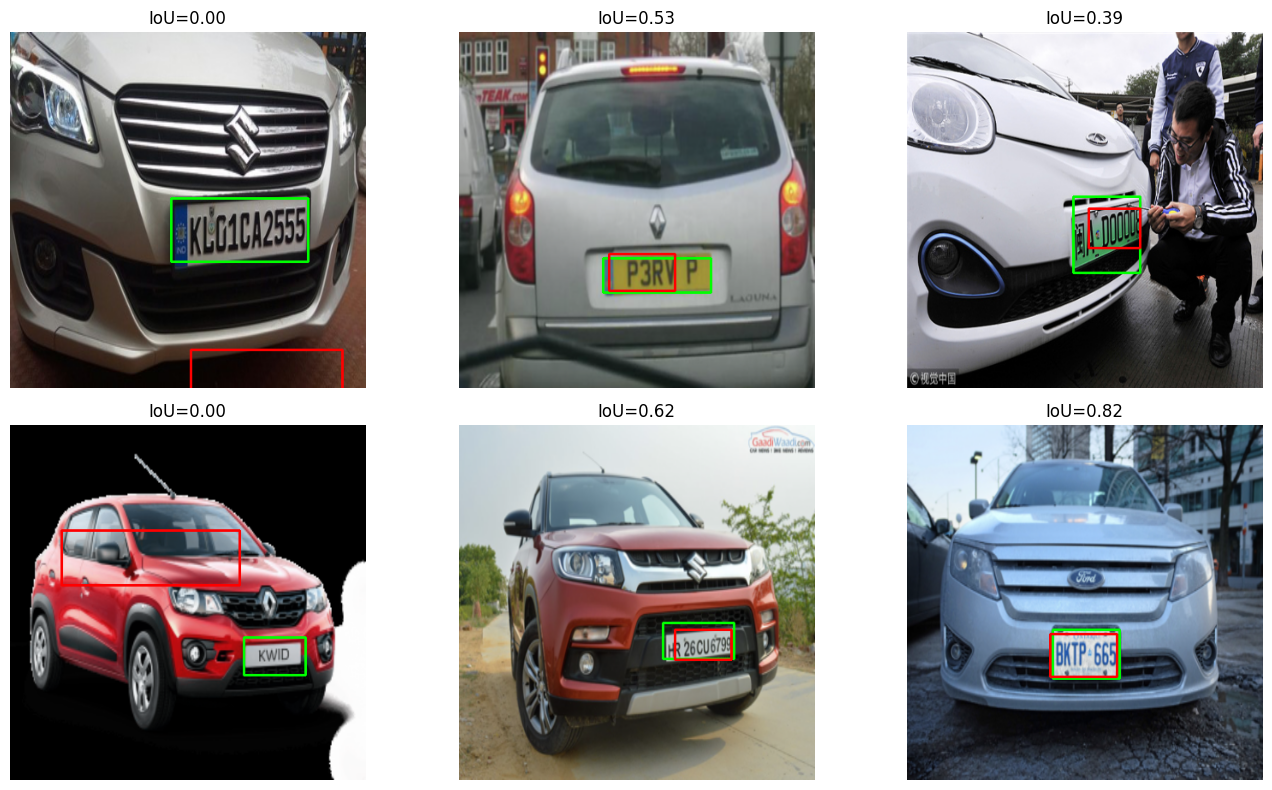

In [12]:
def show_detector_predictions(X, Y_true, Y_pred, n=6):
    idxs = np.random.choice(len(X), size=min(n, len(X)), replace=False)

    plt.figure(figsize=(14, 8))
    for j, idx in enumerate(idxs, 1):
        img = X[idx].copy()
        h, w = img.shape[:2]

        gt = (Y_true[idx] * np.array([w, h, w, h])).astype(int)
        pr = (Y_pred[idx] * np.array([w, h, w, h])).astype(int)

        disp = img.copy()
        cv2.rectangle(disp, (gt[0], gt[1]), (gt[2], gt[3]), (0, 255, 0), 2)
        cv2.rectangle(disp, (pr[0], pr[1]), (pr[2], pr[3]), (255, 0, 0), 2)

        plt.subplot(2, 3, j)
        plt.imshow(disp)
        plt.title(f"IoU={iou_xyxy(Y_true[idx], Y_pred[idx]):.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_detector_predictions(X_test_det, Y_test_det, pred_boxes, n=6)


## Extraction des plaques annotées


In [13]:
extract_rows = []

for row in df.to_dict(orient="records"):
    img = Image.open(row["image_path"]).convert("RGB")
    W, H = img.size

    x1, y1, x2, y2 = row["xmin"], row["ymin"], row["xmax"], row["ymax"]
    bw = x2 - x1
    bh = y2 - y1

    pad_x = max(2, int(bw * 0.08))
    pad_y = max(2, int(bh * 0.15))

    px1 = max(0, x1 - pad_x)
    py1 = max(0, y1 - pad_y)
    px2 = min(W, x2 + pad_x)
    py2 = min(H, y2 + pad_y)

    crop = img.crop((px1, py1, px2, py2))
    crop_path = EXTRACTED_CROPS_DIR / f"{row['id']}_plate.png"
    crop.save(crop_path)

    extract_rows.append({
        "id": row["id"],
        "source_image": row["image_path"],
        "crop_path": str(crop_path),
        "bbox_width": bw,
        "bbox_height": bh,
        "crop_width": px2 - px1,
        "crop_height": py2 - py1,
    })

plates_df = pd.DataFrame(extract_rows)
plates_df.to_csv(PLATES_MANIFEST_CSV, index=False, encoding="utf-8")

print("Plaques extraites :", len(plates_df))
plates_df.head()


Plaques extraites : 433


,id,source_image,crop_path,bbox_width,bbox_height,crop_width,crop_height
0,Cars0,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,193,48,223,62
1,Cars1,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,128,32,148,40
2,Cars10,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,163,143,189,169
3,Cars100,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,39,17,45,21
4,Cars101,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,73,18,83,22


In [14]:
filtered_plates_df = plates_df[
    (plates_df["crop_width"] >= 90) &
    (plates_df["crop_height"] >= 30)
].copy()

print("Plaques conservées pour OCR :", len(filtered_plates_df), "/", len(plates_df))
filtered_plates_df.head()


Plaques conservées pour OCR : 206 / 433


,id,source_image,crop_path,bbox_width,bbox_height,crop_width,crop_height
0,Cars0,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,193,48,223,62
1,Cars1,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,128,32,148,40
2,Cars10,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,163,143,189,169
5,Cars102,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,256,52,296,66
10,Cars107,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,170,51,196,65


## OCR sur plaque entière


In [15]:
try:
    import torch
    import easyocr
    use_gpu = torch.cuda.is_available()
    print("CUDA disponible :", use_gpu)
    if use_gpu:
        print("GPU :", torch.cuda.get_device_name(0))
    reader = easyocr.Reader(['en'], gpu=use_gpu)
    print("EasyOCR initialisé.")
except Exception as e:
    reader = None
    print("EasyOCR indisponible :", e)


Using CPU. Note: This module is much faster with a GPU.


CUDA disponible : False
EasyOCR initialisé.


In [16]:
def deskew_plate(gray_img):
    if len(gray_img.shape) == 3:
        gray = cv2.cvtColor(gray_img, cv2.COLOR_RGB2GRAY)
    else:
        gray = gray_img.copy()

    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = np.column_stack(np.where(th > 0))

    if len(coords) < 20:
        return gray

    rect = cv2.minAreaRect(coords[:, ::-1].astype(np.float32))
    angle = rect[-1]

    if angle < -45:
        angle = 90 + angle
    elif angle > 45:
        angle = angle - 90

    h, w = gray.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(gray, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return rotated

def preprocess_plate_variants(crop_path):
    img = cv2.imread(str(crop_path))
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    scale = 3 if h < 70 else 2 if h < 140 else 1
    gray_big = cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)

    eq = cv2.equalizeHist(gray_big)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray_big)
    blur = cv2.bilateralFilter(eq, 9, 45, 45)

    sharp_kernel = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]])
    sharp = cv2.filter2D(blur, -1, sharp_kernel)

    _, otsu_bin = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_inv = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    adapt_bin = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 9
    )
    adapt_inv = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 9
    )

    morph_close = cv2.morphologyEx(otsu_bin, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    morph_open = cv2.morphologyEx(otsu_bin, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    variants = {
        "rgb": rgb,
        "gray_eq": eq,
        "clahe": clahe,
        "blur": blur,
        "sharp": sharp,
        "otsu_bin": otsu_bin,
        "otsu_inv": otsu_inv,
        "adapt_bin": adapt_bin,
        "adapt_inv": adapt_inv,
        "morph_close": morph_close,
        "morph_open": morph_open,
    }

    extra_variants = {}
    for name, img_var in list(variants.items()):
        if len(img_var.shape) == 2:
            extra_variants[f"{name}_deskew"] = deskew_plate(img_var)

    variants.update(extra_variants)
    return variants


In [17]:
def score_plate_candidate(txt):
    txt = normalize_plate_text(txt)
    compact = compact_plate_text(txt)

    if not compact:
        return -20

    score = 0
    L = len(compact)

    if 5 <= L <= 10:
        score += 12
    elif 4 <= L <= 12:
        score += 6
    else:
        score -= 4

    letters = sum(c.isalpha() for c in compact)
    digits = sum(c.isdigit() for c in compact)

    if letters > 0:
        score += 4
    if digits > 0:
        score += 4
    if letters > 0 and digits > 0:
        score += 8

    if len(set(compact)) <= 2 and L >= 5:
        score -= 8

    repeated_bad = ["IIII", "WWWW", "00000", "11111"]
    for pat in repeated_bad:
        if pat in compact:
            score -= 6

    score += min(L, 10)
    return score

def easyocr_read_variant(img_variant):
    if reader is None:
        return []

    try:
        result = reader.readtext(
            img_variant,
            detail=0,
            paragraph=False,
            allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789- "
        )
        return [normalize_plate_text(x) for x in result if normalize_plate_text(x)]
    except Exception:
        return []

def predict_text_from_crop(crop_path, return_debug=False):
    variants = preprocess_plate_variants(crop_path)
    candidates = []

    for name, img_var in variants.items():
        texts = easyocr_read_variant(img_var)
        for txt in texts:
            candidates.append((name, txt))

    base = variants["gray_eq"]
    for angle in (-3, -2, 2, 3):
        h, w = base.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        rot = cv2.warpAffine(base, M, (w, h), borderValue=255)
        texts = easyocr_read_variant(rot)
        for txt in texts:
            candidates.append((f"rot_{angle}", txt))

    unique_candidates = []
    seen = set()
    for src, txt in candidates:
        key = compact_plate_text(txt)
        if key and key not in seen:
            unique_candidates.append((src, txt))
            seen.add(key)

    ranked = sorted(
        [(score_plate_candidate(txt), src, txt) for src, txt in unique_candidates],
        reverse=True
    )

    best_text = ranked[0][2] if ranked else ""
    best_src = ranked[0][1] if ranked else ""
    alt1 = ranked[1][2] if len(ranked) > 1 else ""
    alt2 = ranked[2][2] if len(ranked) > 2 else ""

    if return_debug:
        return {
            "best_text": best_text,
            "best_variant": best_src,
            "alt1": alt1,
            "alt2": alt2,
            "all_ranked": ranked,
            "variants": variants,
        }

    return best_text


In [18]:
if reader is None:
    raise RuntimeError("EasyOCR n'est pas disponible. Installe-le avec : pip install easyocr torch torchvision")


c:\Users\DELL\Documents\4IIR IA COURS\deep learning\reco-cnn\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Texte prédit : KL01CA2555
Variante choisie : rgb
Alternative 1 : KLO1CA2555
Alternative 2 : KLG1CA2555


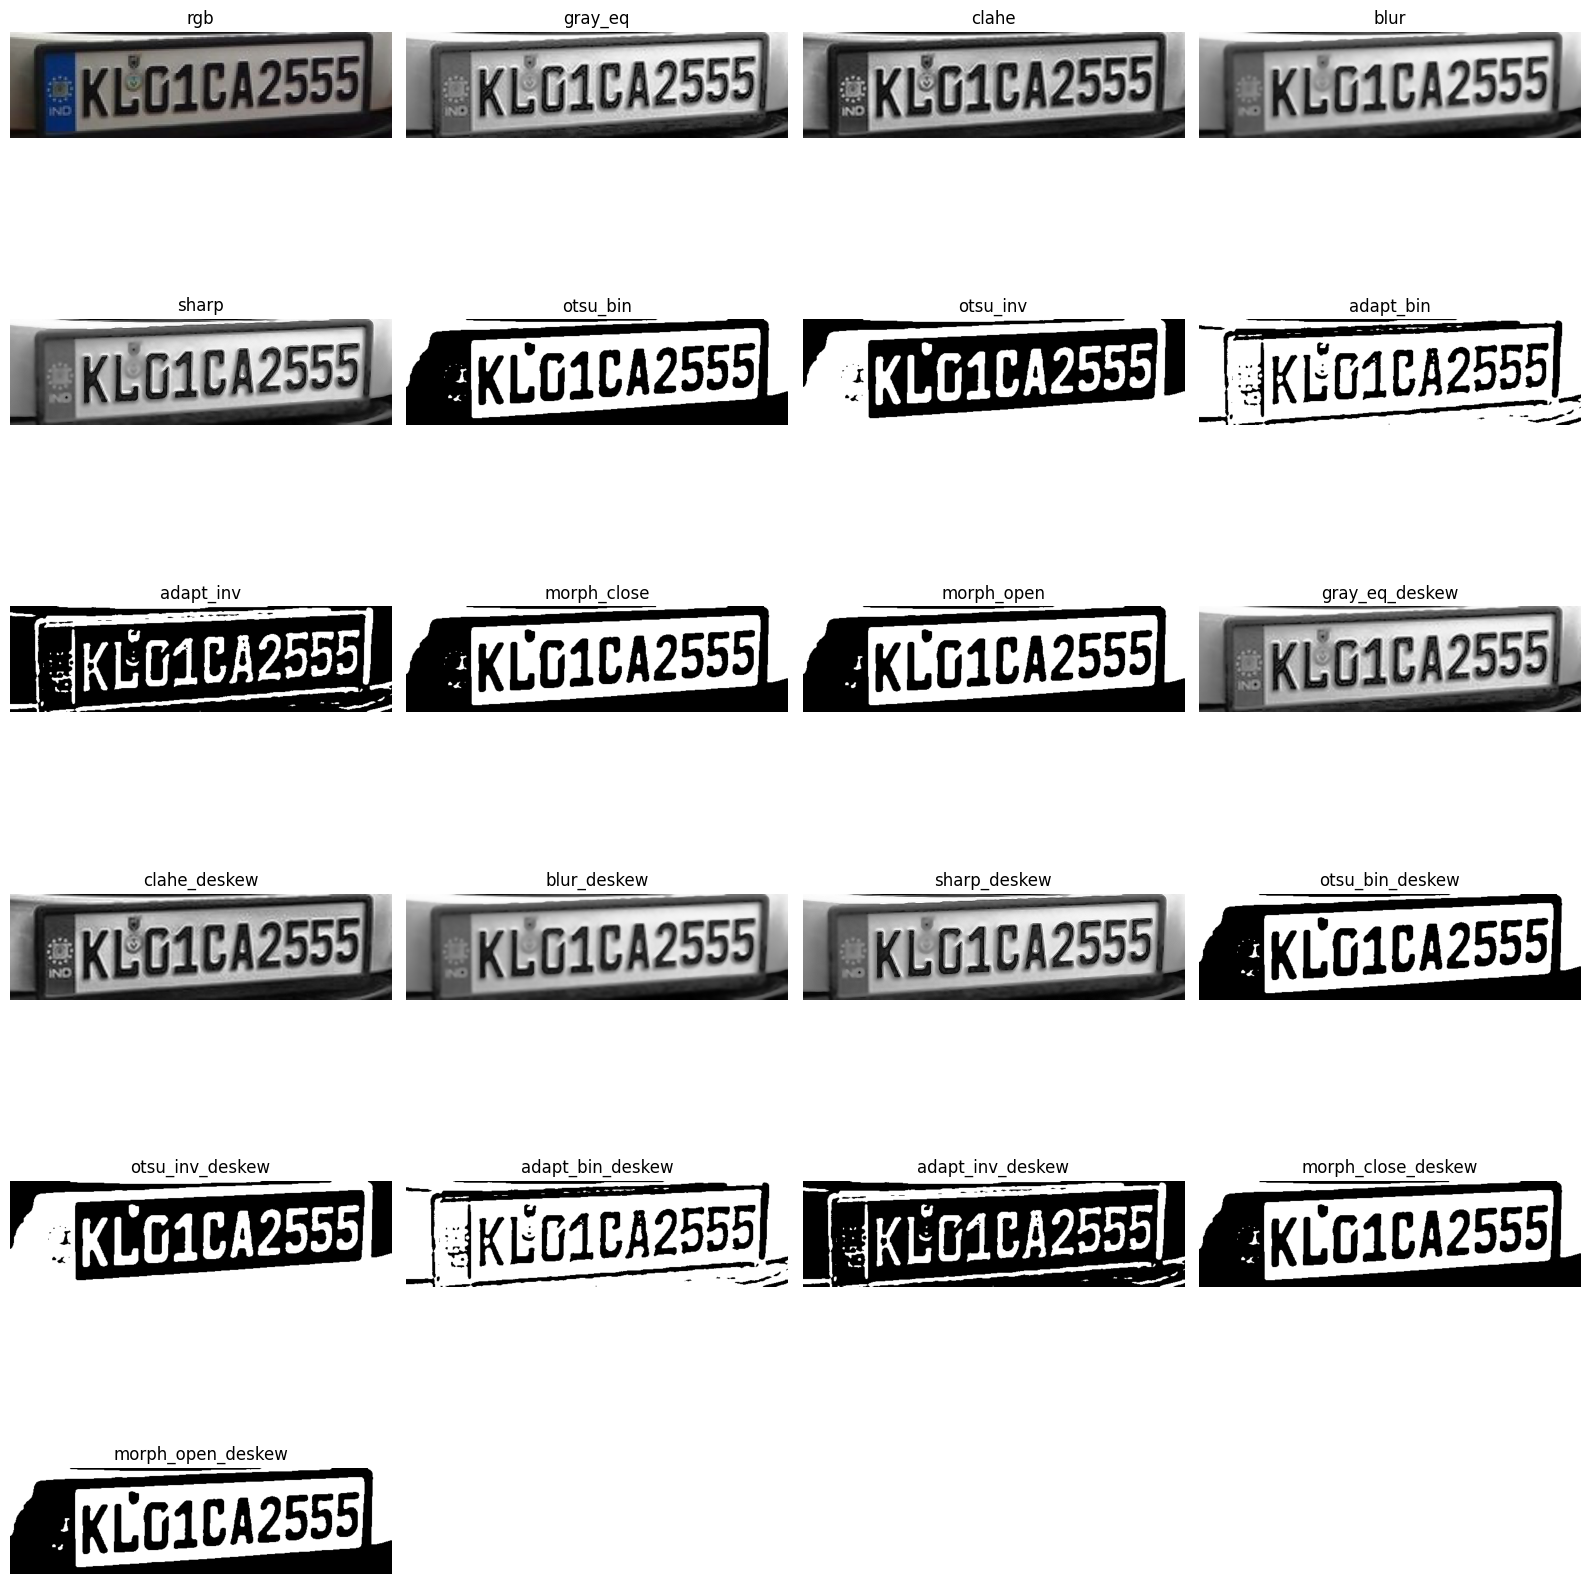

In [19]:
sample_crop = filtered_plates_df.iloc[0]["crop_path"]
debug = predict_text_from_crop(sample_crop, return_debug=True)

print("Texte prédit :", debug["best_text"])
print("Variante choisie :", debug["best_variant"])
print("Alternative 1 :", debug["alt1"])
print("Alternative 2 :", debug["alt2"])

variants_items = list(debug["variants"].items())
n = len(variants_items)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(4 * cols, 3 * rows))

for i, (name, img_var) in enumerate(variants_items, 1):
    plt.subplot(rows, cols, i)
    if len(img_var.shape) == 2:
        plt.imshow(img_var, cmap="gray")
    else:
        plt.imshow(img_var)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Génération des prédictions sur les plaques extraites


In [20]:
pred_rows = []

for row in filtered_plates_df.to_dict(orient="records"):
    debug = predict_text_from_crop(row["crop_path"], return_debug=True)

    pred_rows.append({
        "id": row["id"],
        "crop_path": row["crop_path"],
        "crop_width": row["crop_width"],
        "crop_height": row["crop_height"],
        "predicted_text": debug["best_text"],
        "best_variant": debug["best_variant"],
        "alt_prediction_1": debug["alt1"],
        "alt_prediction_2": debug["alt2"],
        "is_empty_prediction": int(len(compact_plate_text(debug["best_text"])) == 0),
    })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(PREDICTIONS_CSV, index=False, encoding="utf-8")

print("Prédictions générées :", len(pred_df))
pred_df.head(10)


c:\Users\DELL\Documents\4IIR IA COURS\deep learning\reco-cnn\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Prédictions générées : 206


,id,crop_path,crop_width,crop_height,predicted_text,best_variant,alt_prediction_1,alt_prediction_2,is_empty_prediction
0,Cars0,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,223,62,KL01CA2555,rgb,KLO1CA2555,KLG1CA2555,0
1,Cars1,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,148,40,PPGOHN112,adapt_inv,PG WNIT2,PG-NN112,0
2,Cars10,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,189,169,TN 37 C5,rgb,TN37CS,2765,0
3,Cars102,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,296,66,F568561136,otsu_inv,F 683611 36,1 682611 362,0
4,Cars107,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,196,65,MH 2080 20,rgb,MH 2O0080,MH 2000R0,0
5,Cars108,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,137,40,MHO14V8866,sharp,MHO1AV8866,HHO IAV8866,0
6,Cars109,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,189,47,CZI7 KOD,rgb,0B,OB,0
7,Cars11,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,164,36,WORR 516K,adapt_bin,NOR 516K,JOR5I6K,0
8,Cars111,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,183,49,MH 20 EE 7598,rgb,NH 20 EE 7598,NH 0EE7598,0
9,Cars112,c:\Users\DELL\Documents\4IIR IA COURS\deep lea...,133,72,SHAKHBKCL,adapt_bin,FSHAKNBK,SHAKHBKC,0


Taux de prédictions vides : 0.0


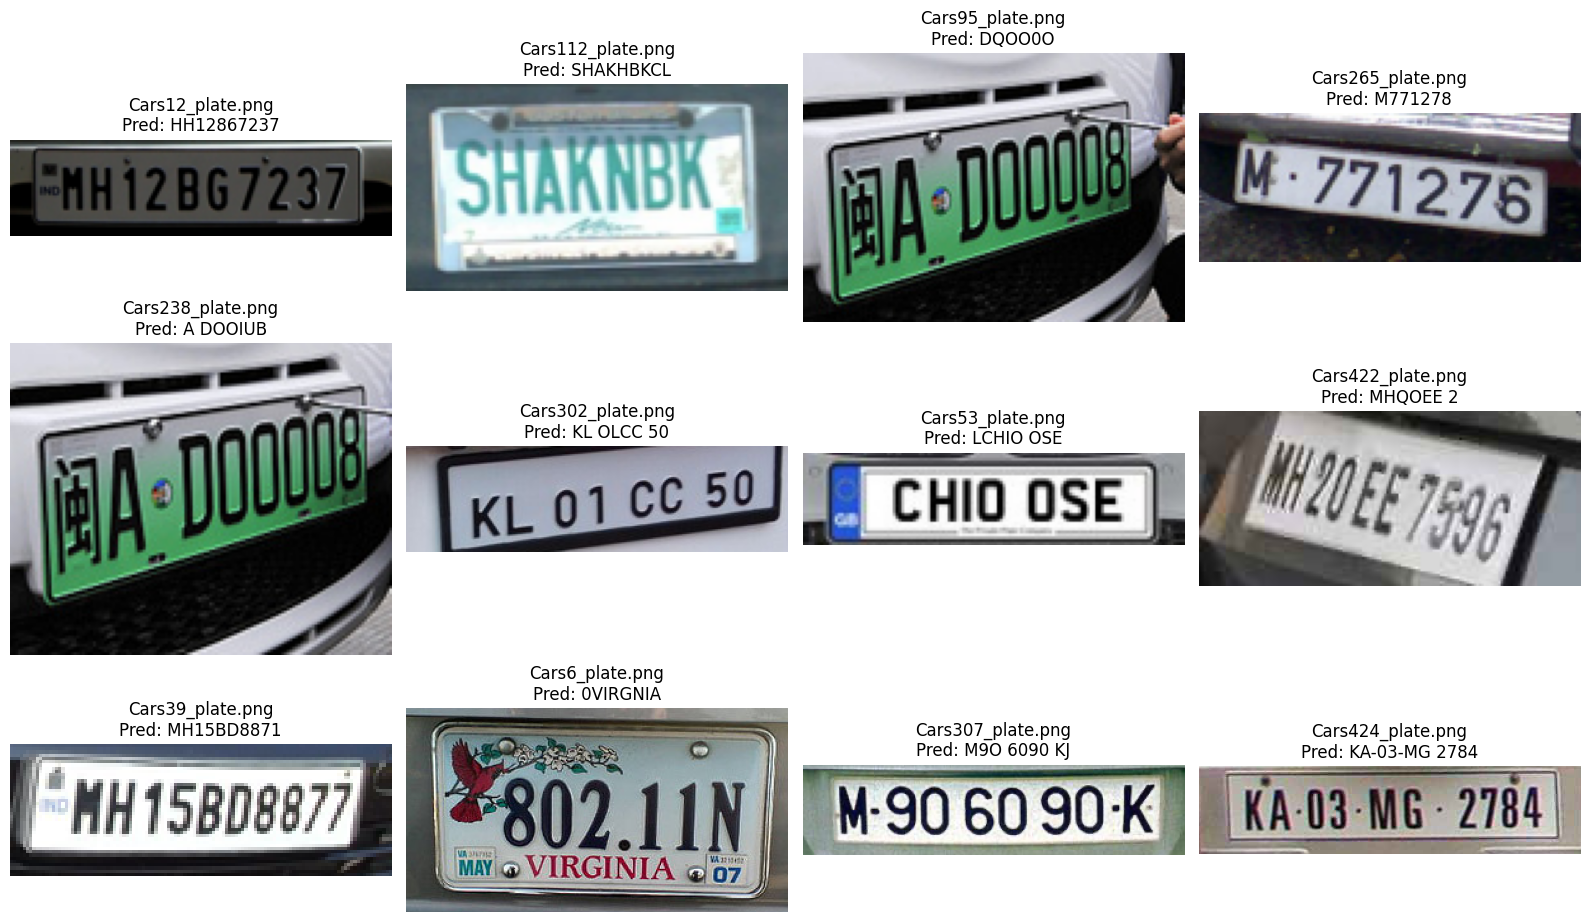

In [21]:
print("Taux de prédictions vides :", pred_df["is_empty_prediction"].mean())

plt.figure(figsize=(16, 10))
sample_pred = pred_df.sample(min(12, len(pred_df)), random_state=SEED).reset_index(drop=True)

for i, row in sample_pred.iterrows():
    plate = load_rgb(row["crop_path"])
    plt.subplot(3, 4, i + 1)
    plt.imshow(plate)
    plt.title(f"{Path(row['crop_path']).name}\nPred: {row['predicted_text']}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Évaluation sur `ground_truth_filled.csv`


In [22]:
if GROUND_TRUTH_FILLED_CSV.exists():
    gt_filled_df = pd.read_csv(GROUND_TRUTH_FILLED_CSV)

    gt_filled_df["use_for_eval"] = pd.to_numeric(gt_filled_df["use_for_eval"], errors="coerce").fillna(0).astype(int)
    gt_filled_df = gt_filled_df[gt_filled_df["use_for_eval"] == 1].copy()

    if len(gt_filled_df) == 0:
        print("Le fichier existe mais aucune ligne n'a use_for_eval = 1")
    else:
        gt_filled_df["id"] = gt_filled_df["id"].astype(str).str.strip()
        pred_df["id"] = pred_df["id"].astype(str).str.strip()

        eval_df = gt_filled_df.merge(
            pred_df[["id", "predicted_text"]],
            on="id",
            how="left"
        )

        eval_df["predicted_text"] = eval_df["predicted_text"].fillna("").astype(str).str.strip()
        eval_df["ground_truth_text"] = eval_df["ground_truth_text"].fillna("").astype(str).str.strip()

        eval_df["exact_match"] = eval_df.apply(
            lambda r: exact_match_norm(r["predicted_text"], r["ground_truth_text"]),
            axis=1
        )
        eval_df["char_accuracy"] = eval_df.apply(
            lambda r: char_accuracy(r["predicted_text"], r["ground_truth_text"]),
            axis=1
        )
        eval_df["is_empty_prediction"] = eval_df["predicted_text"].apply(
            lambda s: int(len(compact_plate_text(s)) == 0)
        )

        eval_df.to_csv(REAL_EVAL_CSV, index=False, encoding="utf-8")

        results = {
            "n_eval": int(len(eval_df)),
            "exact_match_rate": float(eval_df["exact_match"].mean()),
            "mean_char_accuracy": float(eval_df["char_accuracy"].mean()),
            "empty_prediction_rate": float(eval_df["is_empty_prediction"].mean()),
        }

        with open(EVAL_RESULTS_JSON, "w", encoding="utf-8") as f:
            json.dump(results, f, indent=2, ensure_ascii=False)

        print(json.dumps(results, indent=2, ensure_ascii=False))
        display(eval_df[["id", "ground_truth_text", "predicted_text", "exact_match", "char_accuracy"]].head(20))
else:
    print("Aucun fichier ground_truth_filled.csv trouvé dans extracted_plates.")


{
  "n_eval": 60,
  "exact_match_rate": 0.18333333333333332,
  "mean_char_accuracy": 0.36824404761904767,
  "empty_prediction_rate": 0.06666666666666667
}


,id,ground_truth_text,predicted_text,exact_match,char_accuracy
0,Cars114,AP 29 BP 585,CCGRAPHTCE,0,0.111111
1,Cars131,AP 29 BP 585,CCGRAPHTCE,0,0.111111
2,Cars50,PUI8 BES,PUI8 BES,1,1.000000
3,Cars312,PUI8 BES,PUI8 BES,1,1.000000
4,Cars4,PUI8 BES,PUI8 BES,1,1.000000
5,Cars211,F 65022,F 650221,0,1.000000
6,Cars10,TN 37 C5 2765,TN 37 C5,0,0.600000
7,Cars247,TN 37 C5 2765,TN 37 CS5,0,0.500000
8,Cars175,DL 1N 4268,JIN2420L1,0,0.250000
9,Cars6,802.11N,0VIRGNIA,0,0.166667


In [23]:
if REAL_EVAL_CSV.exists():
    err_df = pd.read_csv(REAL_EVAL_CSV)

    err_df["predicted_text"] = err_df["predicted_text"].fillna("").astype(str)
    err_df["ground_truth_text"] = err_df["ground_truth_text"].fillna("").astype(str)

    if "exact_match" not in err_df.columns:
        err_df["exact_match"] = err_df.apply(
            lambda r: exact_match_norm(r["predicted_text"], r["ground_truth_text"]),
            axis=1
        )

    if "char_accuracy" not in err_df.columns:
        err_df["char_accuracy"] = err_df.apply(
            lambda r: char_accuracy(r["predicted_text"], r["ground_truth_text"]),
            axis=1
        )

    err_df["pred_len"] = err_df["predicted_text"].apply(lambda s: len(compact_plate_text(s)))
    err_df["gt_len"] = err_df["ground_truth_text"].apply(lambda s: len(compact_plate_text(s)))

    err_df["error_type"] = "other"
    err_df.loc[err_df["pred_len"] == 0, "error_type"] = "empty"
    err_df.loc[(err_df["pred_len"] < err_df["gt_len"]) & (err_df["pred_len"] > 0), "error_type"] = "too_short"
    err_df.loc[(err_df["pred_len"] > err_df["gt_len"]), "error_type"] = "too_long"
    err_df.loc[(err_df["pred_len"] == err_df["gt_len"]) & (err_df["exact_match"] == 0), "error_type"] = "same_length_wrong"

    print(err_df["error_type"].value_counts())

    display(
        err_df[["id", "ground_truth_text", "predicted_text", "exact_match", "char_accuracy", "error_type"]]
        .sort_values(["exact_match", "char_accuracy"], ascending=[True, True])
        .head(25)
    )
else:
    print("Aucun fichier real_eval_details.csv trouvé.")


error_type
too_short            20
too_long             17
same_length_wrong    11
other                 8
empty                 4
Name: count, dtype: int64


,id,ground_truth_text,predicted_text,exact_match,char_accuracy,error_type
12,Cars176,EV09 FTW,VEUQ9ETL,0,0.000000,too_long
13,Cars385,EV09 FTW,OR4CBOIE,0,0.000000,too_long
15,Cars279,MMN 306,S3OOL,0,0.000000,too_short
17,Cars61,MMN 306,GT0114,0,0.000000,same_length_wrong
20,Cars158,695299,COSTA RICA,0,0.000000,too_long
21,Cars97,KA G5MG1909,05HG19027,0,0.000000,too_short
27,Cars398,MMN 306,0910YO7A,0,0.000000,too_long
34,Cars180,MPEACHW,WASHINGTON,0,0.000000,too_long
35,Cars45,IMGROOT,,0,0.000000,empty
41,Cars113,MPEACHW,WASHINGTON,0,0.000000,too_long


## Résultats finaux


In [24]:
results = {
    "detector": det_metrics,
    "real_plate_predictions": {
        "n_filtered_plates": int(len(filtered_plates_df)),
        "empty_prediction_rate": float(pred_df["is_empty_prediction"].mean()),
    }
}

if EVAL_RESULTS_JSON.exists():
    with open(EVAL_RESULTS_JSON, "r", encoding="utf-8") as f:
        results["real_eval"] = json.load(f)

with open(FINAL_RESULTS_JSON, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(json.dumps(results, indent=2, ensure_ascii=False))


{
  "detector": {
    "mean_iou": 0.42271775007247925,
    "median_iou": 0.5144262313842773,
    "iou_gt_0_5": 0.5230769230769231,
    "iou_gt_0_7": 0.13846153846153847,
    "no_detection": 0
  },
  "real_plate_predictions": {
    "n_filtered_plates": 206,
    "empty_prediction_rate": 0.0
  },
  "real_eval": {
    "n_eval": 60,
    "exact_match_rate": 0.18333333333333332,
    "mean_char_accuracy": 0.36824404761904767,
    "empty_prediction_rate": 0.06666666666666667
  }
}


## Vérifications rapides


In [25]:
def smoke_test():
    assert IMG_DIR.exists(), "Le dossier images n'existe pas"
    assert ANN_DIR.exists(), "Le dossier annotations n'existe pas"
    assert len(list(IMG_DIR.glob("*"))) > 0, "Aucune image trouvée"
    assert len(list(ANN_DIR.glob("*.xml"))) > 0, "Aucune annotation XML trouvée"
    print("Test 1 OK - Dossiers présents")

    assert len(df) > 0, "DataFrame vide"
    print("Test 2 OK - Données chargées")

    assert DETECTOR_WEIGHTS.exists(), "Poids détecteur absents"
    print("Test 3 OK - Détecteur disponible")

    assert PLATES_MANIFEST_CSV.exists(), "Manifest des plaques non créé"
    print("Test 4 OK - Plaques extraites")

    assert PREDICTIONS_CSV.exists(), "Prédictions sur plaques non générées"
    print("Test 5 OK - Prédictions générées")

    print("Tous les smoke tests sont validés.")

smoke_test()


Test 1 OK - Dossiers présents
Test 2 OK - Données chargées
Test 3 OK - Détecteur disponible
Test 4 OK - Plaques extraites
Test 5 OK - Prédictions générées
Tous les smoke tests sont validés.
